Module1

Скачиваем библиотеки для работы с изображениями и аудио

In [ ]:
#%pip install "numpy<2.2" --user
#%pip install seaborn matplotlib librosa catboost lightgbm xgboost


Импортируем необходимые библиотеки для работы с данными

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import librosa as lb
import soundfile as sf
from PIL import Image
import seaborn as sns

Считываем входные данные

In [2]:
#Извлекаем аудио
paths = ['C:\\Users\\Patifon\\Downloads\\Telegram Desktop\\Stud_IT_2025_Module_12\\training_datasets\\audio\\train\\',
         'D:\\TestJupyter\\data\\Stud_IT_2025_Module_1\\training_datasets\\audio\\train\\']
df = pd.DataFrame()
data_list = []
for i in range(0, 13):
    path = paths[1] + str(i)
    fileNames = os.listdir(path)
    for file in fileNames:
        filePath = path + '\\' + file
        y, sr = lb.load(filePath)
        row = {
            'label': i, 
            'frequence': sr,
            'audio_signal': y
        }
        data_list.append(row)
df_audio = pd.DataFrame(data_list)



In [3]:
df = df_audio
df['audio_signal'].info()


<class 'pandas.Series'>
RangeIndex: 3806 entries, 0 to 3805
Series name: audio_signal
Non-Null Count  Dtype 
--------------  ----- 
3806 non-null   object
dtypes: object(1)
memory usage: 29.9+ KB


In [4]:
def get_features(y, sr, mfc):
    mfcc = lb.feature.mfcc(y=y, sr=sr, n_mfcc=mfc)
    
    # 1. Среднее по времени
    mfcc_mean = np.mean(mfcc.T, axis=0)
    # 2. Стандартное отклонение (важно для ритмичных звуков)
    mfcc_std = np.std(mfcc.T, axis=0)
    # 3. Дельты (динамика)
    delta = np.mean(lb.feature.delta(mfcc).T, axis=0)
    
    # Склеиваем всё в один вектор (60 признаков)
    return np.concatenate([mfcc_mean, mfcc_std, delta])

Создаем модель

In [5]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Ridge
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [6]:
X = np.stack(df.apply(lambda r: get_features(r['audio_signal'], r['frequence'], 30), axis=1))
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

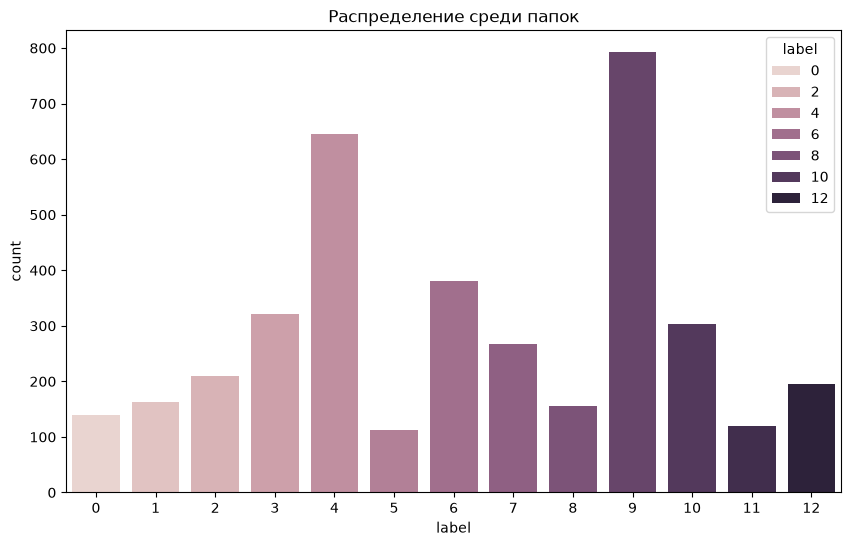

In [8]:
plt.figure(figsize=(10, 6))
sns.countplot(x='label', data = df, hue='label')
plt.title('Распределение среди папок')
plt.show()

In [9]:
target_length = 3806
def process_signal(sig):
    if len(sig) > target_length:
        return sig[:target_length]
    return np.pad(sig, (0, target_length - len(sig)))
x = np.stack(df['audio_signal'].apply(process_signal))

In [10]:
correlation_df = pd.DataFrame(X)
correlation_df

,0,1,2,3,4,5,6,7,8,9,...,80,81,82,83,84,85,86,87,88,89
0,-326.953156,126.732819,18.722376,33.616943,12.163055,20.199926,4.315989,6.741365,4.242728,14.248836,...,-0.005610,-0.009724,-0.003547,-0.003668,-0.022182,-0.022442,-0.001866,-0.018428,-0.028213,0.012704
1,-144.917664,165.948120,-7.243530,30.202246,4.446951,16.722300,10.067258,0.148226,-1.974138,5.352202,...,0.019071,0.001172,-0.007016,-0.007407,0.004815,-0.002490,-0.016833,0.000264,0.008765,0.000022
2,-88.896751,101.917664,-92.023888,16.646507,-24.563147,-5.093263,-13.647749,10.392327,-18.875317,15.619473,...,0.007730,0.026595,0.002927,-0.015162,-0.043716,0.018212,0.008680,0.009091,-0.033473,0.008460
3,-327.268402,139.102356,-21.198210,26.536379,4.634921,16.655075,0.125408,13.508964,4.033756,9.991028,...,-0.016719,0.005437,0.041019,0.047695,-0.001966,-0.011990,0.005655,0.001423,-0.010060,-0.000440
4,-258.347839,169.280273,22.084698,34.691833,12.883649,2.105325,1.140517,3.167859,0.179440,-9.194927,...,-0.041154,-0.023418,0.004813,-0.000879,-0.019416,-0.023305,-0.003197,0.010011,0.029046,0.005449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3801,-259.029419,104.444405,6.194714,3.030196,9.374902,11.519267,-10.236611,8.283175,-5.758993,8.264499,...,-0.020625,-0.030535,-0.041022,-0.027110,0.010394,0.007519,-0.011320,-0.011498,-0.000420,0.003437
3802,-367.795746,68.311783,29.626921,38.849552,10.285570,23.904221,12.603636,21.876011,11.624248,7.298285,...,-0.006880,0.018772,0.002683,0.031294,0.005386,-0.020792,0.012674,0.013967,0.010915,0.005399
3803,-284.630554,170.985886,-12.944889,24.019444,-3.672869,-11.615574,9.299925,2.712571,2.179493,7.516245,...,0.013573,0.004588,-0.042573,0.005707,0.000618,-0.010930,0.010369,0.011922,-0.000791,-0.000907
3804,-322.258240,160.042633,-9.852104,33.250996,-22.175327,6.148643,-15.644409,6.164412,-6.202765,1.872015,...,-0.011812,0.007755,-0.006922,0.000225,0.005432,-0.015564,-0.002772,0.008731,0.013836,0.031975


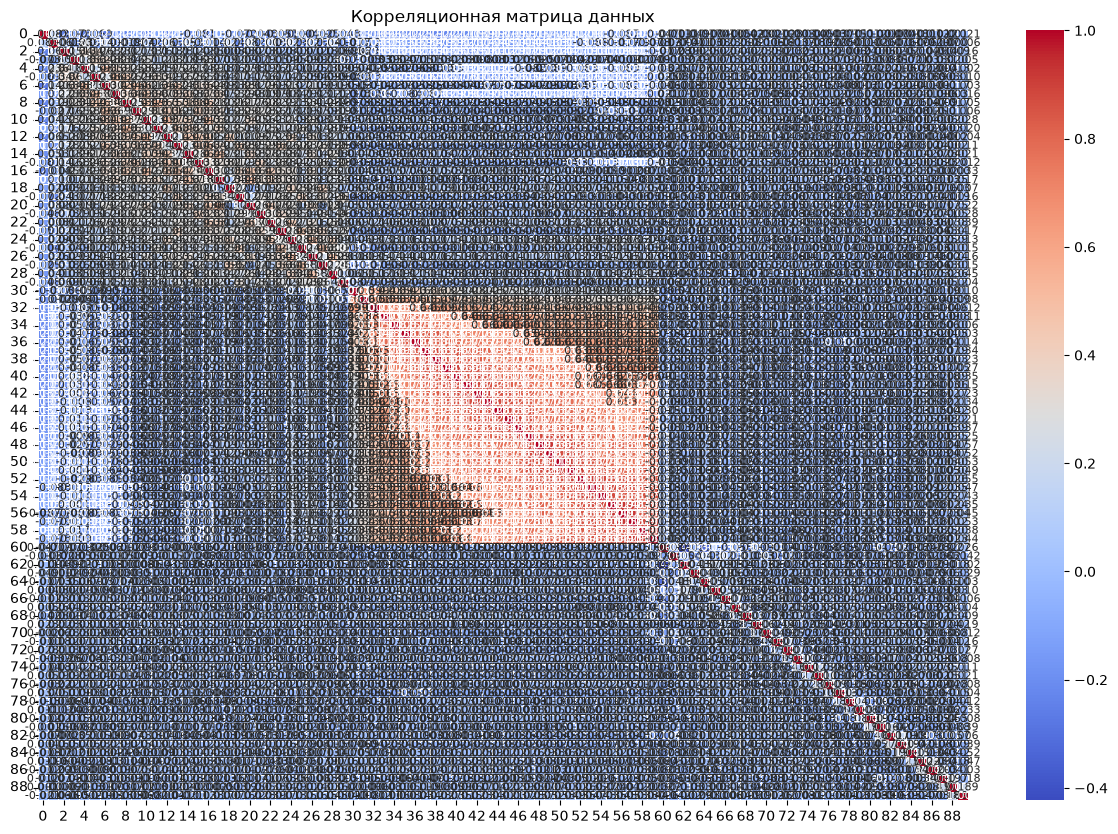

In [11]:

plt.figure(figsize = (15, 10))
ax = sns.heatmap(
    correlation_df.corr(),
    annot = True,
    fmt = '.3f',
    cmap = 'coolwarm',
    linewidths = .5,
    annot_kws = {"size": 8}
) 
plt.xticks(rotation = 0)
plt.yticks(rotation = 0)
plt.title('Корреляционная матрица данных')
plt.show()

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [13]:
Xs_train = []
ys_train = []
Xs_test = []
ys_test = []
for i in range(5, 101, 5):
    Xs = np.stack(df.apply(lambda r: get_features(r['audio_signal'], r['frequence'], i), axis=1))
    X_train1, X_test1, y_train1, y_test1 = train_test_split(Xs, y)
    Xs_train.append(scaler.fit_transform(X_train1))
    Xs_test.append(scaler.transform(X_test1))
    ys_train.append(y_train1)
    ys_test.append(y_test1)
    
    

KeyboardInterrupt: 

In [ ]:
best_score = []
scores_mfcc = {}
for i in range(len(Xs_train)):
    test_forest = RandomForestClassifier(class_weight='balanced', n_estimators=29)
    test_forest.fit(Xs_train[i], ys_train[i])
    predict_mfcc = test_forest.predict(Xs_test[i])
    for func in [
        accuracy_score,
        classification_report
    ]:
        score_mfcc = func(ys_test[i], predict_mfcc)
        model_name_mfcc = i
        if isinstance(score_mfcc, (float, int)):
            
            print(f'model: {model_name_mfcc}, Accuracy: {score_mfcc:.4f}')
            scores_mfcc[test_forest.__class__.__name__] = score_mfcc
            best_score.append(score_mfcc)
        else:
            print(f'model: {model_name_mfcc}, Accuracy: \n{score_mfcc}')

In [ ]:
print(max(best_score))

In [ ]:
from xgboost import XGBClassifier
scores = {}
for model in [
    #LogisticRegression(),
    #DecisionTreeClassifier(),
    RandomForestClassifier(class_weight='balanced', n_estimators=29),
    XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6),
    #LGBMClassifier(verbose = -1),
    CatBoostClassifier(verbose = 0)
]:
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    for func in [
        accuracy_score,
        
        #confusion_matrix,
        classification_report
    ]:
        score = func(y_test, preds)
        model_name = model.__class__.__name__
        if isinstance(score, (float, int)):
            
            print(f'model: {model_name}, Accuracy: {score:.4f}')
            scores[model.__class__.__name__] = score
        else:
            print(f'model: {model_name}, Accuracy: \n{score}')

написть из 6 машинки пункт 1.3 с переобучением)))

In [ ]:
accuracy = []

for n in range(10, 100):
    forest_model = RandomForestClassifier(n_estimators=n, class_weight='balanced', max_features='sqrt')
    forest_model.fit(X_train_scaled, y_train)
    prediction = forest_model.predict(X_test_scaled)
    accuracy.append(accuracy_score(prediction, y_test))


In [ ]:
plt.figure(figsize=(20, 10))
plt.xticks(range(10, 101))
plt.plot(range(10, 100), accuracy, label='Accuracy')
plt.legend()

In [ ]:
max(accuracy)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [10, 25, 50, 100],
    'max_features': ['sqrt', 'log2'],
    'max_depth' : [4,6,8],
    'criterion' :['gini', 'entropy']
}

CV_rfc = GridSearchCV(estimator=forest_model, param_grid=param_grid, cv= 5)
CV_rfc.fit(X_train_scaled, y_train)

print(CV_rfc.best_params_)

model_best = RandomForestClassifier(**CV_rfc.best_params_)
model_best.fit(X_train_scaled, y_train)

accuracy_CV = model_best.score(X_test_scaled, y_test)
print(f"Точность улучшенной модели: {accuracy_CV}")

In [ ]:
model_catboost = CatBoostClassifier(
    loss_function='MultiClass', 
    random_seed=101,
    silence = True
    
)

param_grid_1 = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6]
}

grid_search_1 = GridSearchCV(
    estimator=model_catboost, 
    param_grid=param_grid_1, 
    cv=3,
    verbose=2,
    error_score='raise'
)

grid_search_1.fit(X_train_scaled, y_train)

best_params = grid_search_1.best_params_
print(f'Лучшие параметры: {best_params}')

best_model_catboost = CatBoostClassifier(
    
    iterations=best_params['iterations'],
    learning_rate=best_params['learning_rate'],
    depth=best_params['depth'],
    loss_function='MultiClass',
    random_seed=101,
    silence = True
    
)

best_model_catboost.fit(X_train_scaled, y_train)

accuracy = best_model_catboost.score(X_test_scaled, y_test)
print(f'Точность улучшенной модели CatBoost: {accuracy}')




In [ ]:
best_model_catboost = CatBoostClassifier(
    iterations=best_params['iterations'],
    learning_rate=best_params['learning_rate'],
    depth=best_params['depth'],
    loss_function='MultiClass',
    random_seed=101,
    verbose=False
)

best_model_catboost.fit(X_train_scaled, y_train)

accuracy_CT = best_model_catboost.score(X_test_scaled, y_test)
print(f'Точность улучшенной модели CatBoost: {accuracy_CT}')


In [ ]:
val_path = "D:\\TestJupyter\\data\\Stud_IT_2025_Module_1\\training_datasets\\audio\\val"

